**predict future prices**

***Objective***

The goal is to use historical stock data to predict the next day's closing price.

In [1]:
!pip install yfinance

import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

***Load Dataset***

In [2]:
data = yf.download('AAPL', start='2022-01-01', end='2024-01-01')

data.head()

/tmp/ipykernel_7707/3953495052.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2022-01-01', end='2024-01-01')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,178.103638,178.954976,173.895938,174.013357,104487900
2022-01-04,175.843262,179.013730,175.275708,178.710386,99310400
2022-01-05,171.165833,176.303156,170.891843,175.755177,94537600
2022-01-06,168.308472,171.537649,167.956198,168.993445,96904000
2022-01-07,168.474823,170.402543,167.359291,169.179371,86709100


***Data preprocessing***

In [13]:

data['Next_Day_Close'] = data['Close'].shift(-1)
data.dropna(inplace=True)

X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Next_Day_Close']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

***Evaluation***

In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [16]:
y_pred = model.predict(X_test)

***Evaluation***

In [17]:
mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 2.1797050323486324


***Visualization***

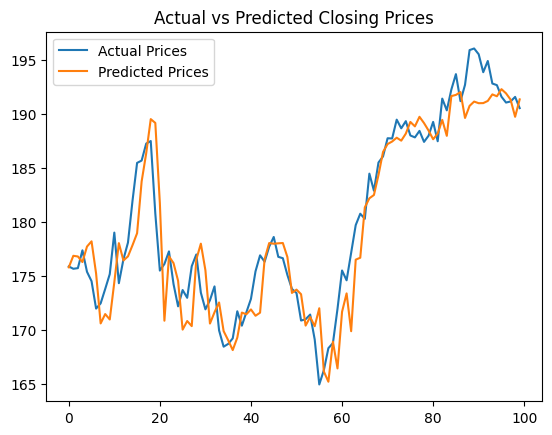

In [18]:
plt.figure()
plt.plot(y_test.values, label='Actual Prices')
plt.plot(y_pred, label='Predicted Prices')
plt.legend()
plt.title("Actual vs Predicted Closing Prices")
plt.show()

**Results and Insights**

- The model was able to predict closing prices with reasonable accuracy.
- Mean Absolute Error (MAE) shows average prediction error.
- Predicted values follow the trend of actual prices.
- Some differences exist due to market volatility.


**Conclusion**

  We successfully built a stock price prediction model using historical data.

This task helped understand:  
- Time series data handling
- Regression modeling
- Real-world API data usage